In [147]:
import os, sys
sys.path.append('../scripts')
import snp_path  # noqa: F401  # scripts/ subfolders -> sys.path
import dcpp_decadal_handles
import mi_vectorized 
import smyle_metrics 
import matplotlib.pyplot as plt 
import numpy as np

dcpp_decadal_handles.inventory();


SLP: obs = hadslp2r_monthly_1850_2019.nc, canonical window covered for s1960..s2009
  model               run (months)  starts  usable for a decade
  CanESM5                      120      60  yes   [s1960..s2019]
  EC-Earth3                122-132      60  yes   [s1960..s2019]
  HadGEM3-GC31-MM              125      59  yes   [s1960..s2018]
  MIROC6                       122      62  yes   [s1960..s2021]
  MPI-ESM1-2-LR                122      62  yes   [s1960..s2021]
  MRI-ESM2-0                    62      60  NO -- shorter than 120   [s1960..s2019]
  NorCPM1                      123      59  yes   [s1960..s2018]
  -> 50 decade(s) with all 6 long models AND observations: s1960..s2009

TREFHT: obs = ncep_air2m_monthly.nc, canonical window covered for s1960..s2015
  model               run (months)  starts  usable for a decade
  CanESM5                      120      60  yes   [s1960..s2019]
  EC-Earth3                122-132      60  yes   [s1960..s2019]
  HadGEM3-GC31-MM              

In [23]:
def remove_ticks(axs):
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])

def add_colorbars(fig, ims, axs, fraction=0.04, pad=0.2):
    for i, im in enumerate(ims):
        fig.colorbar(im, ax=axs[i], fraction=fraction, pad=pad)

In [27]:
data = dcpp_decadal_handles.get(1961, var='SLP')
F = data.F 
o = data.o
s = np.mean(F, axis=0)

<Decade DCPP-A s1961 (6 models) SLP, 1962-01..1971-12 monthly [Pa]: N=92 T=120, anom=moy, smooth 11.25x12.5deg>
    CanESM5            N= 20  lead 1 = 1962-01  target months are leads 1..120
    EC-Earth3          N= 16  lead 1 = 1961-11  target months are leads 3..122
    HadGEM3-GC31-MM    N= 10  lead 1 = 1961-11  target months are leads 3..122
    MIROC6             N= 10  lead 1 = 1961-11  target months are leads 3..122
    MPI-ESM1-2-LR      N= 16  lead 1 = 1961-11  target months are leads 3..122
    NorCPM1            N= 20  lead 1 = 1961-10  target months are leads 4..123


In [28]:
rho_o = smyle_metrics.pearson_coeff(s, o)
rho_m = smyle_metrics.ensemble_SNR_loo(F)

In [54]:
K_NN = 4
USE_COPULA = True 

lam_of = smyle_metrics.lam_of
lam_o_LOO = lam_of(smyle_metrics.calc_MI_sG_LOOavg(F, o, k=K_NN, use_copula=USE_COPULA))
lam_o = lam_of(smyle_metrics.calc_MI_sG(s, o, k=K_NN, use_copula=USE_COPULA))
lam_m = lam_of(smyle_metrics.calc_MI_sF(F, k=K_NN, use_copula=USE_COPULA))

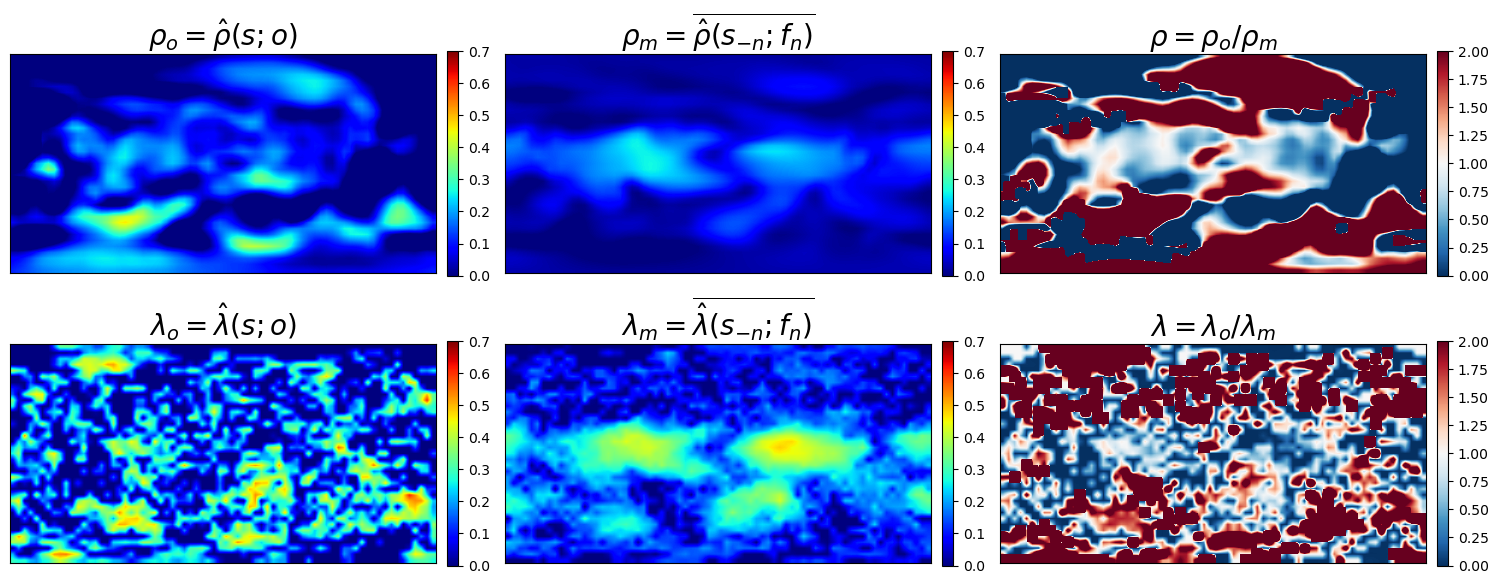

In [300]:
FONT_SIZE = 20
CLIM_UPPER_1 = 0.7
CLIM_UPPER_2 = 2.0
KWARGS_1 = {'cmap': 'jet', 'vmin': 0.0, 'vmax':CLIM_UPPER_1, 'interpolation':'bilinear'}
KWARGS_2 = {'cmap': 'RdBu_r', 'vmin': 0.0, 'vmax':CLIM_UPPER_2, 'interpolation':'bilinear'}

fig, axs = plt.subplots(2, 3, figsize=(15, 6))
axs=axs.flatten()

im0 = axs[0].imshow(rho_o, **KWARGS_1)
im1 = axs[1].imshow(rho_m, **KWARGS_1)
im2 = axs[2].imshow(rho_o / rho_m, **KWARGS_2)
im3 = axs[3].imshow(lam_o_LOO, **KWARGS_1)
im4 = axs[4].imshow(lam_m, **KWARGS_1)
im5 = axs[5].imshow(lam_o_LOO / lam_m, **KWARGS_2)
ims = [im0, im1, im2, im3, im4, im5]

axs[0].set_title('$\\rho_o=\\hat\\rho(s;o)$', fontsize=FONT_SIZE)
axs[1].set_title('$\\rho_m=\\overline{\\hat\\rho(s_{-n};f_n)}$', fontsize=FONT_SIZE)
axs[2].set_title('$\\rho = \\rho_o / \\rho_m$', fontsize=FONT_SIZE)
axs[3].set_title('$\\lambda_o=\\hat\\lambda(s;o)$', fontsize=FONT_SIZE)
axs[4].set_title('$\\lambda_m=\\overline{\\hat\\lambda(s_{-n};f_n)}$', fontsize=FONT_SIZE)
axs[5].set_title('$\\lambda = \\lambda_o / \\lambda_m$', fontsize=FONT_SIZE)

remove_ticks(axs)
add_colorbars(fig, ims, axs, fraction=0.025, pad=0.025) 
plt.tight_layout()

Text(0.5, 1.0, '$\\lambda_o$')

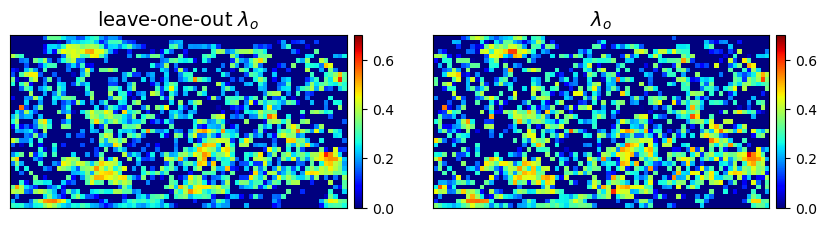

In [68]:
FONT_SIZE=14

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

im0 = axs[0].imshow(lam_o_LOO, **KWARGS_1)
im1 = axs[1].imshow(lam_o, **KWARGS_1)
ims = [im0, im1]

remove_ticks(axs)
add_colorbars(fig, ims, axs, fraction=0.0245, pad=0.02)

axs[0].set_title('leave-one-out $\\lambda_o$', fontsize=FONT_SIZE)
axs[1].set_title('$\\lambda_o$', fontsize=FONT_SIZE)


In [83]:
def pearson_coeff_pairwise(F, o):
    """Pearson correlation between member and obs -> (N_MEMBER, N_LAT, N_LON) """
    def helper_mean(X):
        return np.mean(X, axis=1).reshape(X.shape[0], -1, X.shape[2], X.shape[3])
        
    num = np.mean((F - helper_mean(F)) * (o - helper_mean(o)), axis=1)
    den = np.std(F, axis=1) * np.std(o, axis=1)
    return num / den
    
def pearson_coeff_F_pairwise(F):
    """
        Pearson correlation between member pairs ->  (N_MEMBER, N_MEMBER, N_LAT, N_LON)
    """
    centered = F - np.mean(F, axis=1, keepdims=True)

    # Sum of cross-products for every member pair.
    numerator = np.einsum("ntxy,mtxy->nmxy", centered, centered, optimize=True,)

    sum_squares = np.sum(centered * centered, axis=1)
    denominator = np.sqrt(sum_squares[:, None, :, :] * sum_squares[None, :, :, :])

    with np.errstate(divide="ignore", invalid="ignore"):
        return numerator / denominator

In [84]:
o_tiled = np.broadcast_to(o, (F.shape[0], o.shape[0], o.shape[1], o.shape[2]))
print(o_tiled.shape)
assert np.abs(np.mean(o_tiled, axis=0) - o).all() <= 1e-7, 'Tiling observations were not successful.'

(92, 120, 37, 72)


In [199]:
rho_o_pairwise = pearson_coeff_pairwise(F, o_tiled)
rho_m_pairwise = pearson_coeff_F_pairwise(F)
print(rho_o_pairwise.shape)
print(rho_m_pairwise.shape)

(92, 37, 72)
(92, 92, 37, 72)


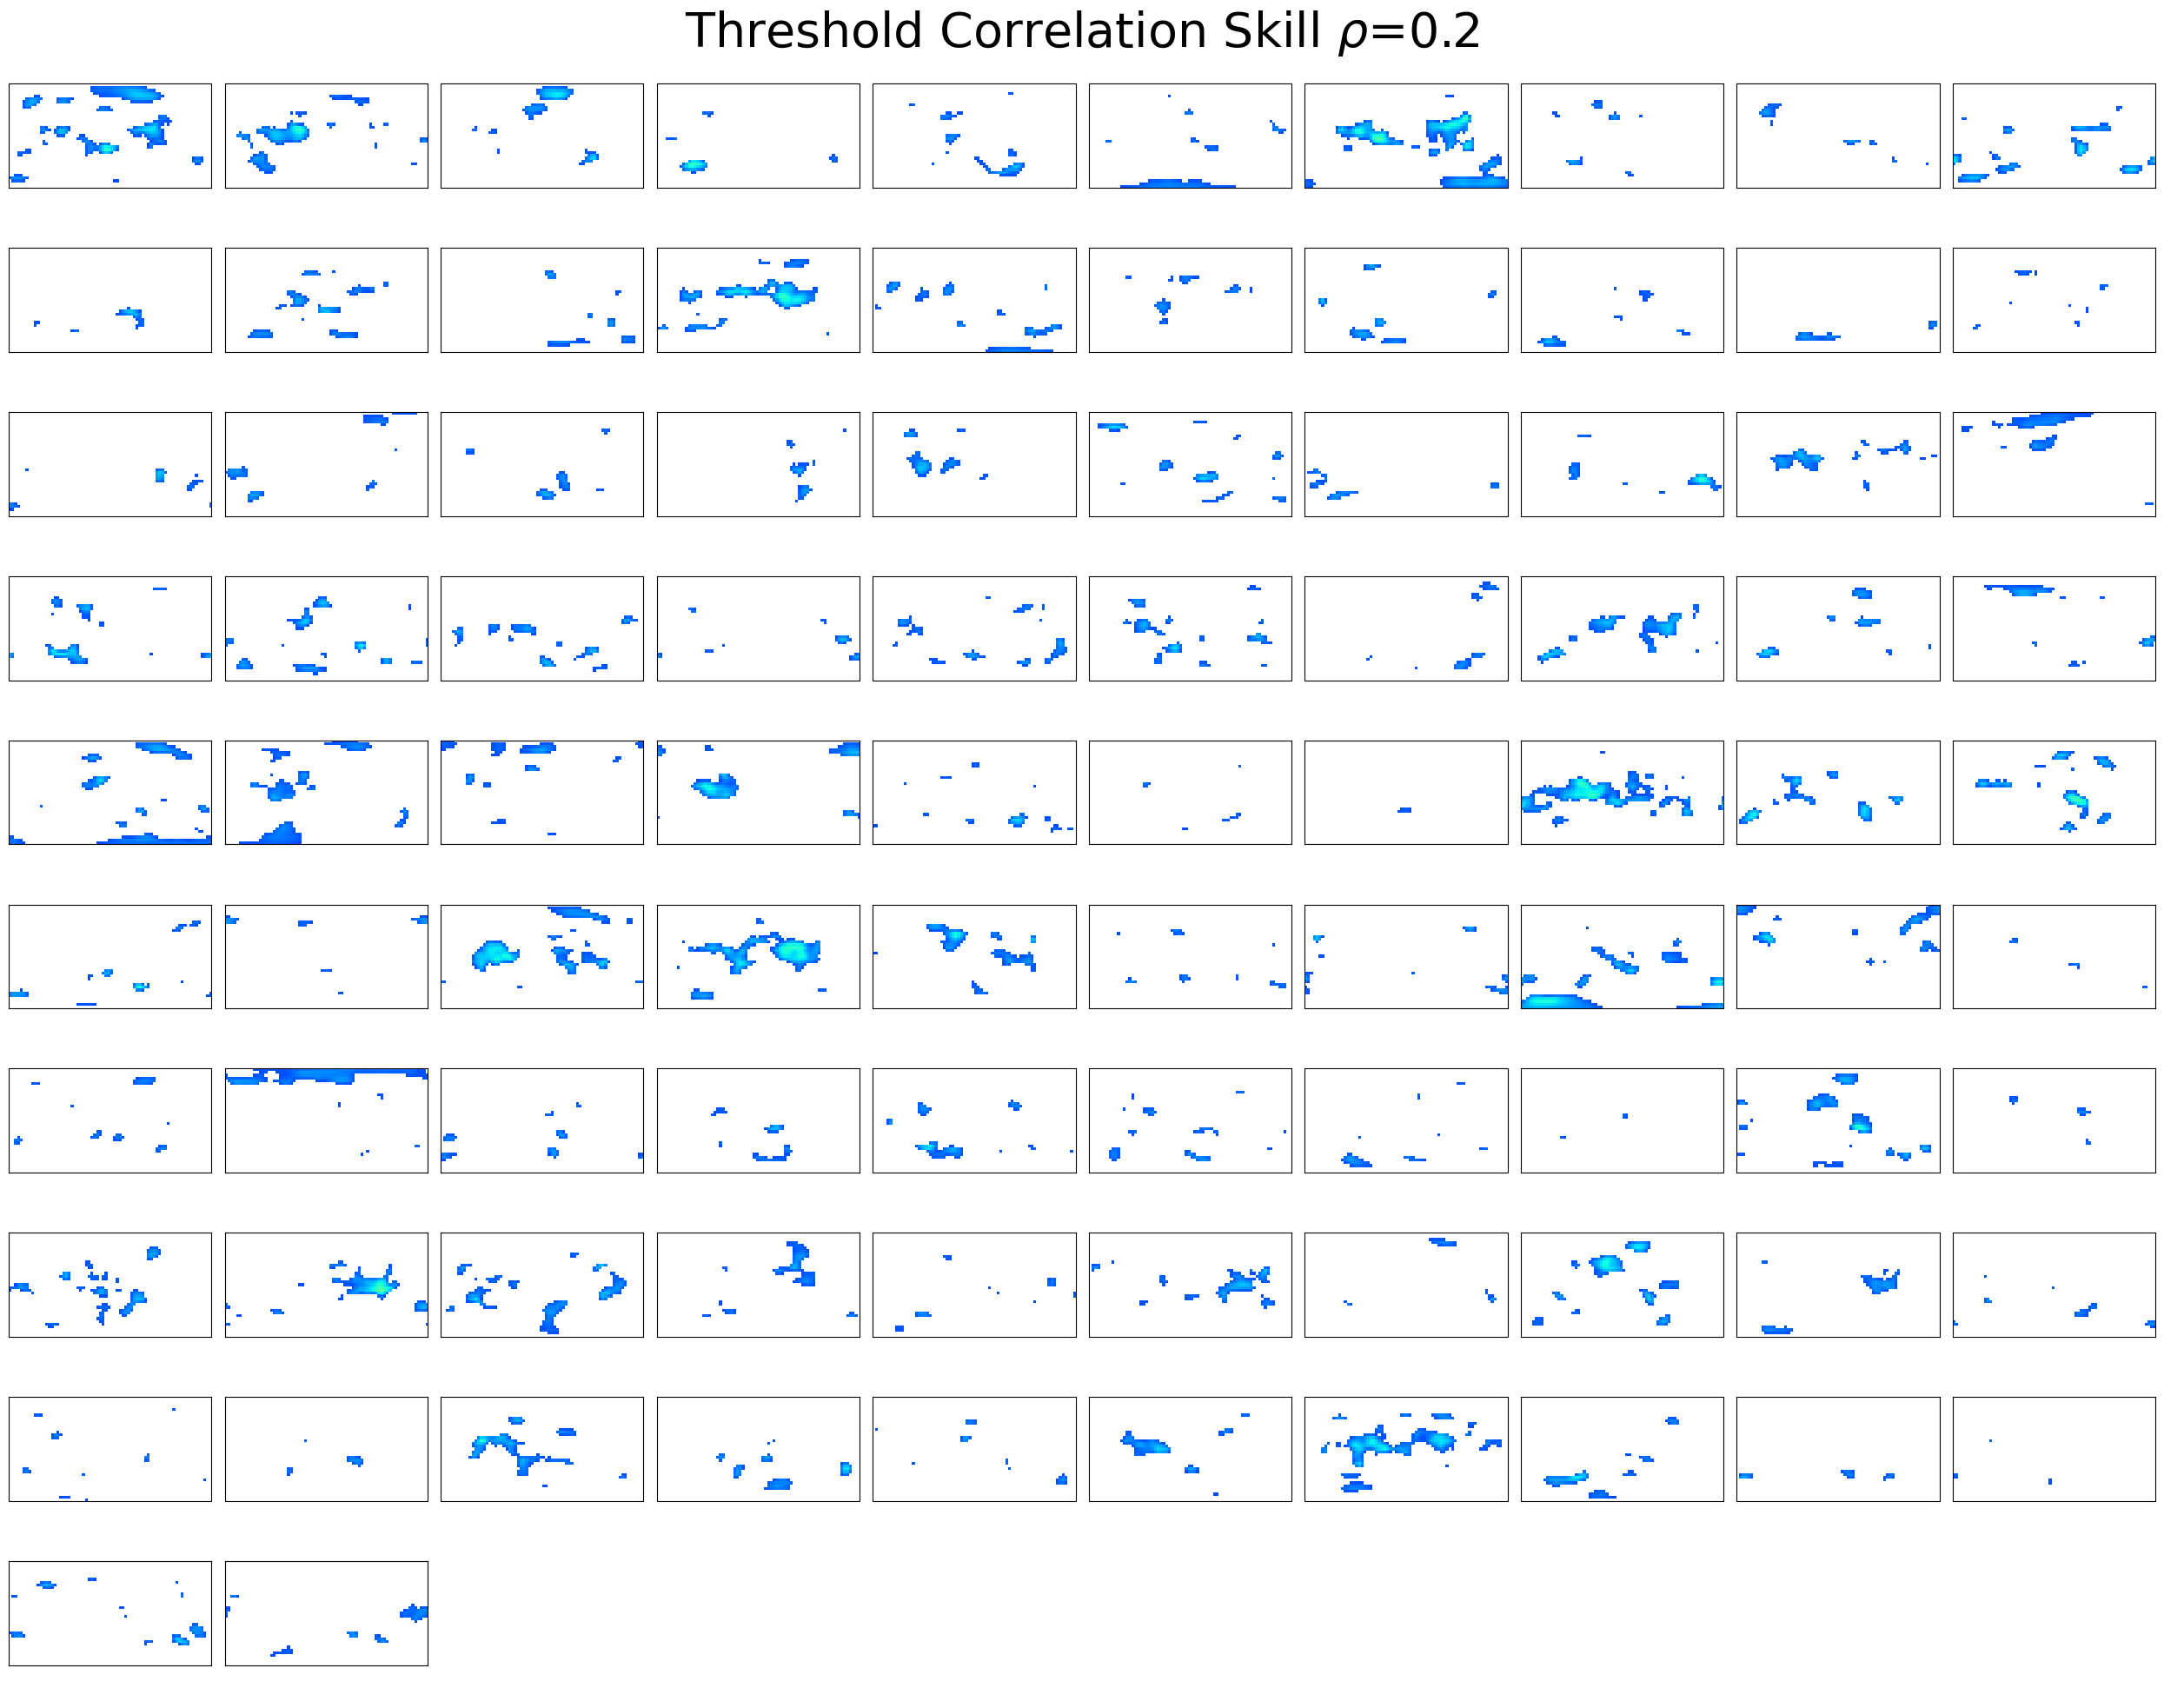

In [145]:
N_SQUARE = 10
CORR_THRESHOLD = 0.2

frac_skill_area = [] 

fig, axs = plt.subplots(N_SQUARE, N_SQUARE, figsize=(25, 20))
axs = axs.flatten()
for i in range(N_SQUARE * N_SQUARE):
    if i<rho_o_pairwise.shape[0]:
        rho_o_tmp = rho_o_pairwise[i, :, :].copy()
        rho_o_tmp[rho_o_tmp<CORR_THRESHOLD] = np.nan
        frac_skill_area.append(np.sum(np.where(np.isnan(rho_o_tmp.flatten()), 0.0, 1.0))/rho_o_tmp.size)
        axs[i].imshow(rho_o_tmp, cmap='jet', vmin=0, vmax=1.0)
        # axs[i].set_title(f'$n={i}$', fontsize=20)
    else:
        for spine in ["top", "bottom", "left", "right"]:
            axs[i].spines[spine].set_visible(False)
        
remove_ticks(axs)
plt.suptitle(f'Threshold Correlation Skill $\\rho$={CORR_THRESHOLD}', fontsize=40)
plt.tight_layout()

Text(0, 0.5, 'Number of Ensemble Members')

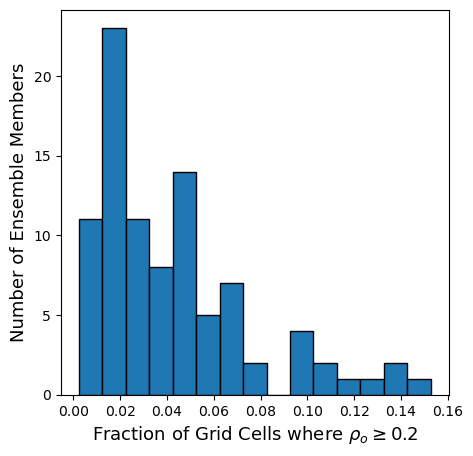

In [132]:
FONT_SIZE=13

fig, axs = plt.subplots(1, 1, figsize=(5, 5))

axs.hist(frac_skill_area, bins=15, ec='k')

axs.set_xlabel(f'Fraction of Grid Cells where $\\rho_o\\geq${CORR_THRESHOLD}', fontsize=FONT_SIZE)
axs.set_ylabel('Number of Ensemble Members', fontsize=FONT_SIZE)

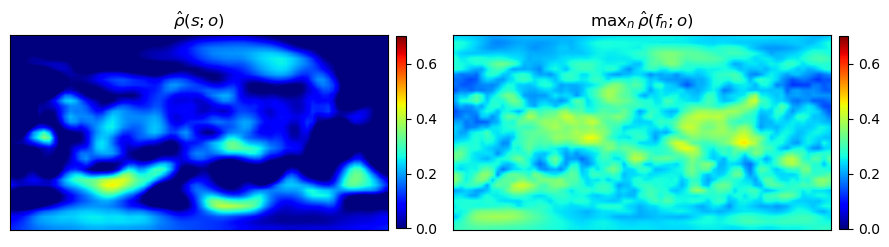

In [306]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
im0 = axs[0].imshow(rho_o, cmap='jet', 
                    vmin=0, vmax=0.7, interpolation='bilinear')
im1 = axs[1].imshow(np.max(rho_o_pairwise, axis=0), cmap='jet', 
                    vmin=0, vmax=0.7, interpolation='bilinear')
ims = [im0, im1]
add_colorbars(fig, ims, axs, fraction=0.0243, pad=0.02)
remove_ticks(axs)

axs[0].set_title('$\\hat \\rho(s; o)$', fontsize=12)
axs[1].set_title('max$_n\,\\hat \\rho(f_n; o)$', fontsize=12)

plt.tight_layout()
# axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

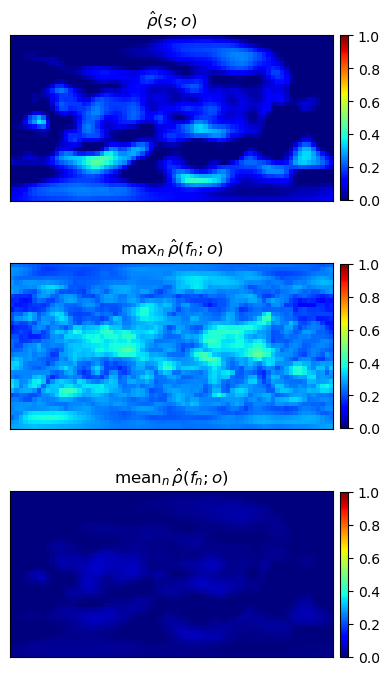

In [133]:
fig, axs = plt.subplots(3, 1, figsize=(4, 7))
im0 = axs[0].imshow(rho_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(np.max(rho_o_pairwise, axis=0), cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(np.mean(rho_o_pairwise, axis=0), cmap='jet', vmin=0.0, vmax=1.0)
ims = [im0, im1, im2]
add_colorbars(fig, ims, axs, fraction=0.0243, pad=0.02)
remove_ticks(axs)

axs[0].set_title('$\\hat \\rho(s; o)$', fontsize=12)
axs[1].set_title('max$_n\,\\hat \\rho(f_n; o)$', fontsize=12)
axs[2].set_title('mean$_n\,\\hat \\rho(f_n; o)$', fontsize=12)
plt.tight_layout()
# axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

Text(0.5, 0.98, '$\\rho_j=\\frac{\\text{max}_{n\\neq j}\\,\\hat \\rho(f_n; o)}{\\text{max}_{n\\neq j}\\,\\hat \\rho(f_n; f_j)}$')

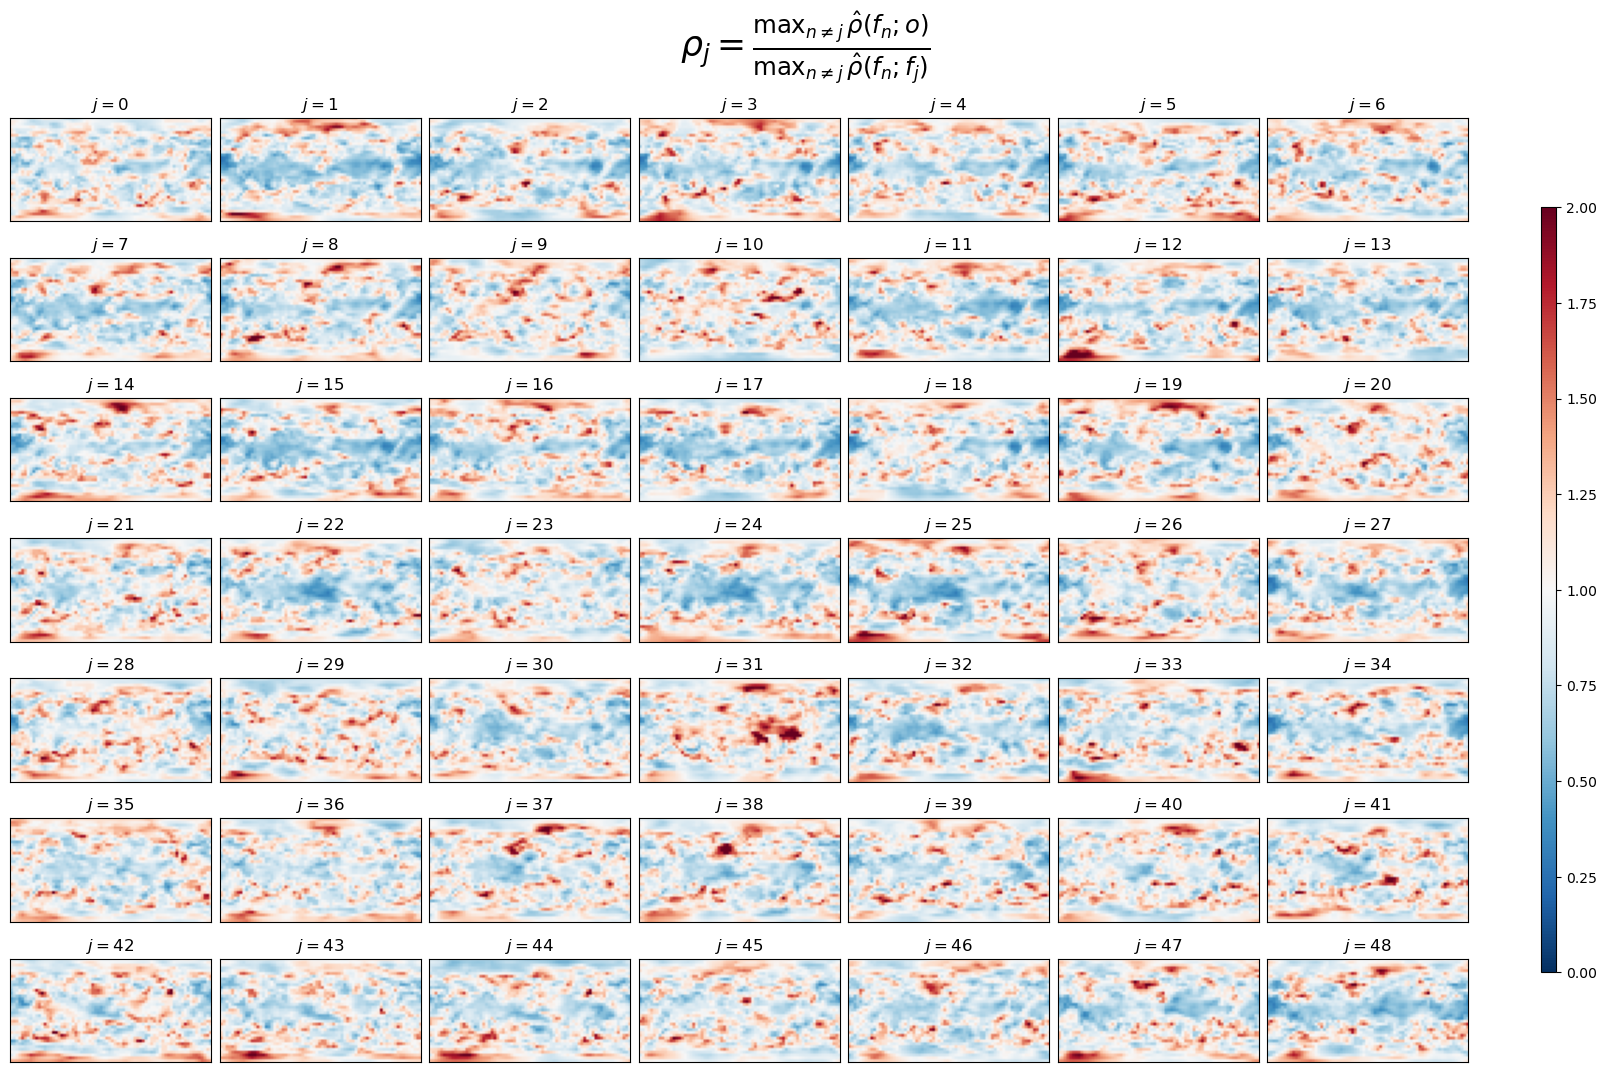

In [311]:
# 1. Add layout="compressed" to your figure initialization
fig, axs = plt.subplots(7, 7, figsize=(16, 12), layout="compressed")
axs = axs.flatten() 

for i in range(len(axs)):
    if i < rho_m_pairwise.shape[0]:
        # compute maximum potential skill of ensemble on obs
        obs_pairwise = rho_o_pairwise.copy() 
        obs_pairwise[i, :, :] = np.nan 
        rho_o_max = np.nanmax(obs_pairwise, axis=0)

        # compute maximum potential skill of ensemble on held-out member
        member_pairwise = rho_m_pairwise[i, :, :, :].copy()
        member_pairwise[i, :, :] = np.nan
        rho_m_max = np.nanmax(member_pairwise, axis=0)

        # show "RPC"
        im = axs[i].imshow(rho_o_max / rho_m_max, vmin=0, vmax=2.0, cmap='RdBu_r')
        axs[i].set_title(f'$j={i}$')
    else:
        for spine in ["top", "bottom", "left", "right"]:
            axs[i].spines[spine].set_visible(False)
            
remove_ticks(axs)

# 2. Add your global colorbar
fig.colorbar(im, ax=axs.ravel(), orientation="vertical", shrink=0.8, aspect=50)   

# 3. Add suptitle (it naturally centers perfectly now)
plt.suptitle('$\\rho_j=\\frac{\\text{max}_{n\\neq j}\\,\\hat \\rho(f_n; o)}{\\text{max}_{n\\neq j}\\,\\hat \\rho(f_n; f_j)}$', fontsize=25)


In [218]:
K_NN = 4
# N_MEMBER_SUBSET = -1
MI_FG_pairwise = mi_vectorized.mi_member_vs_obs(F, o, k=K_NN, n_jobs=-1, copula=True)
MI_F_pairwise = mi_vectorized.mi_member_vs_member(F, k=K_NN, n_jobs=-1, copula=True)

In [219]:
lam_o_pairwise = lam_of(MI_FG_pairwise)
lam_m_pairwise = lam_of(MI_F_pairwise)

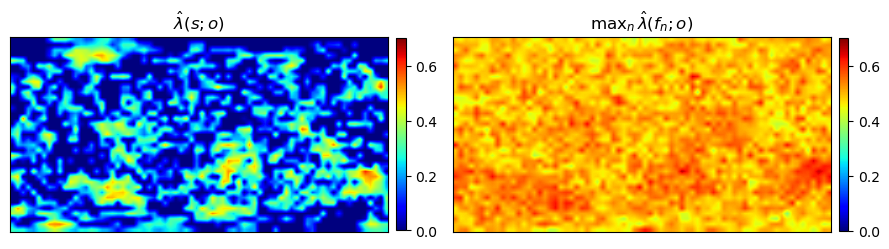

In [308]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
im0 = axs[0].imshow(lam_o_LOO, cmap='jet', 
                    vmin=0, vmax=0.7, interpolation='bilinear')
im1 = axs[1].imshow(np.max(lam_o_pairwise, axis=0), cmap='jet', 
                    vmin=0, vmax=0.7, interpolation='bilinear')
ims = [im0, im1]
add_colorbars(fig, ims, axs, fraction=0.0243, pad=0.02)
remove_ticks(axs)

axs[0].set_title('$\\hat \\lambda(s; o)$', fontsize=12)
axs[1].set_title('max$_n\,\\hat \\lambda(f_n; o)$', fontsize=12)

plt.tight_layout()
# axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

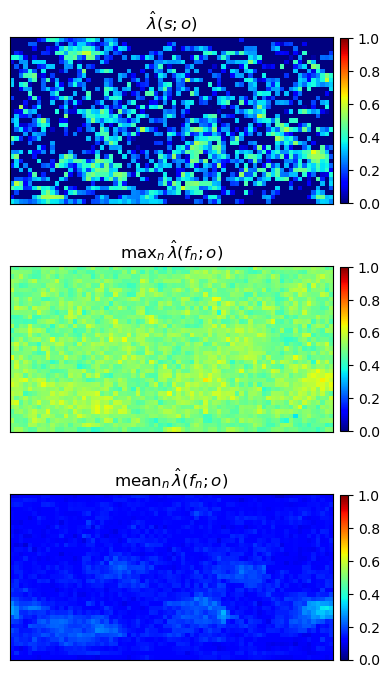

In [220]:
fig, axs = plt.subplots(3, 1, figsize=(4, 7))
im0 = axs[0].imshow(lam_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(np.max(lam_o_pairwise, axis=0), cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(np.mean(lam_o_pairwise, axis=0), cmap='jet', vmin=0.0, vmax=1.0)
fig.colorbar(im0, ax=axs[0], fraction=0.0243, pad=0.02)
fig.colorbar(im1, ax=axs[1], fraction=0.0243, pad=0.02)
fig.colorbar(im2, ax=axs[2], fraction=0.0243, pad=0.02)

remove_ticks(axs)

axs[0].set_title('$\\hat \\lambda(s; o)$', fontsize=12)
axs[1].set_title('max$_n\,\\hat \\lambda(f_n; o)$', fontsize=12)
axs[2].set_title('mean$_n\,\\hat \\lambda(f_n; o)$', fontsize=12)
plt.tight_layout()
# axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

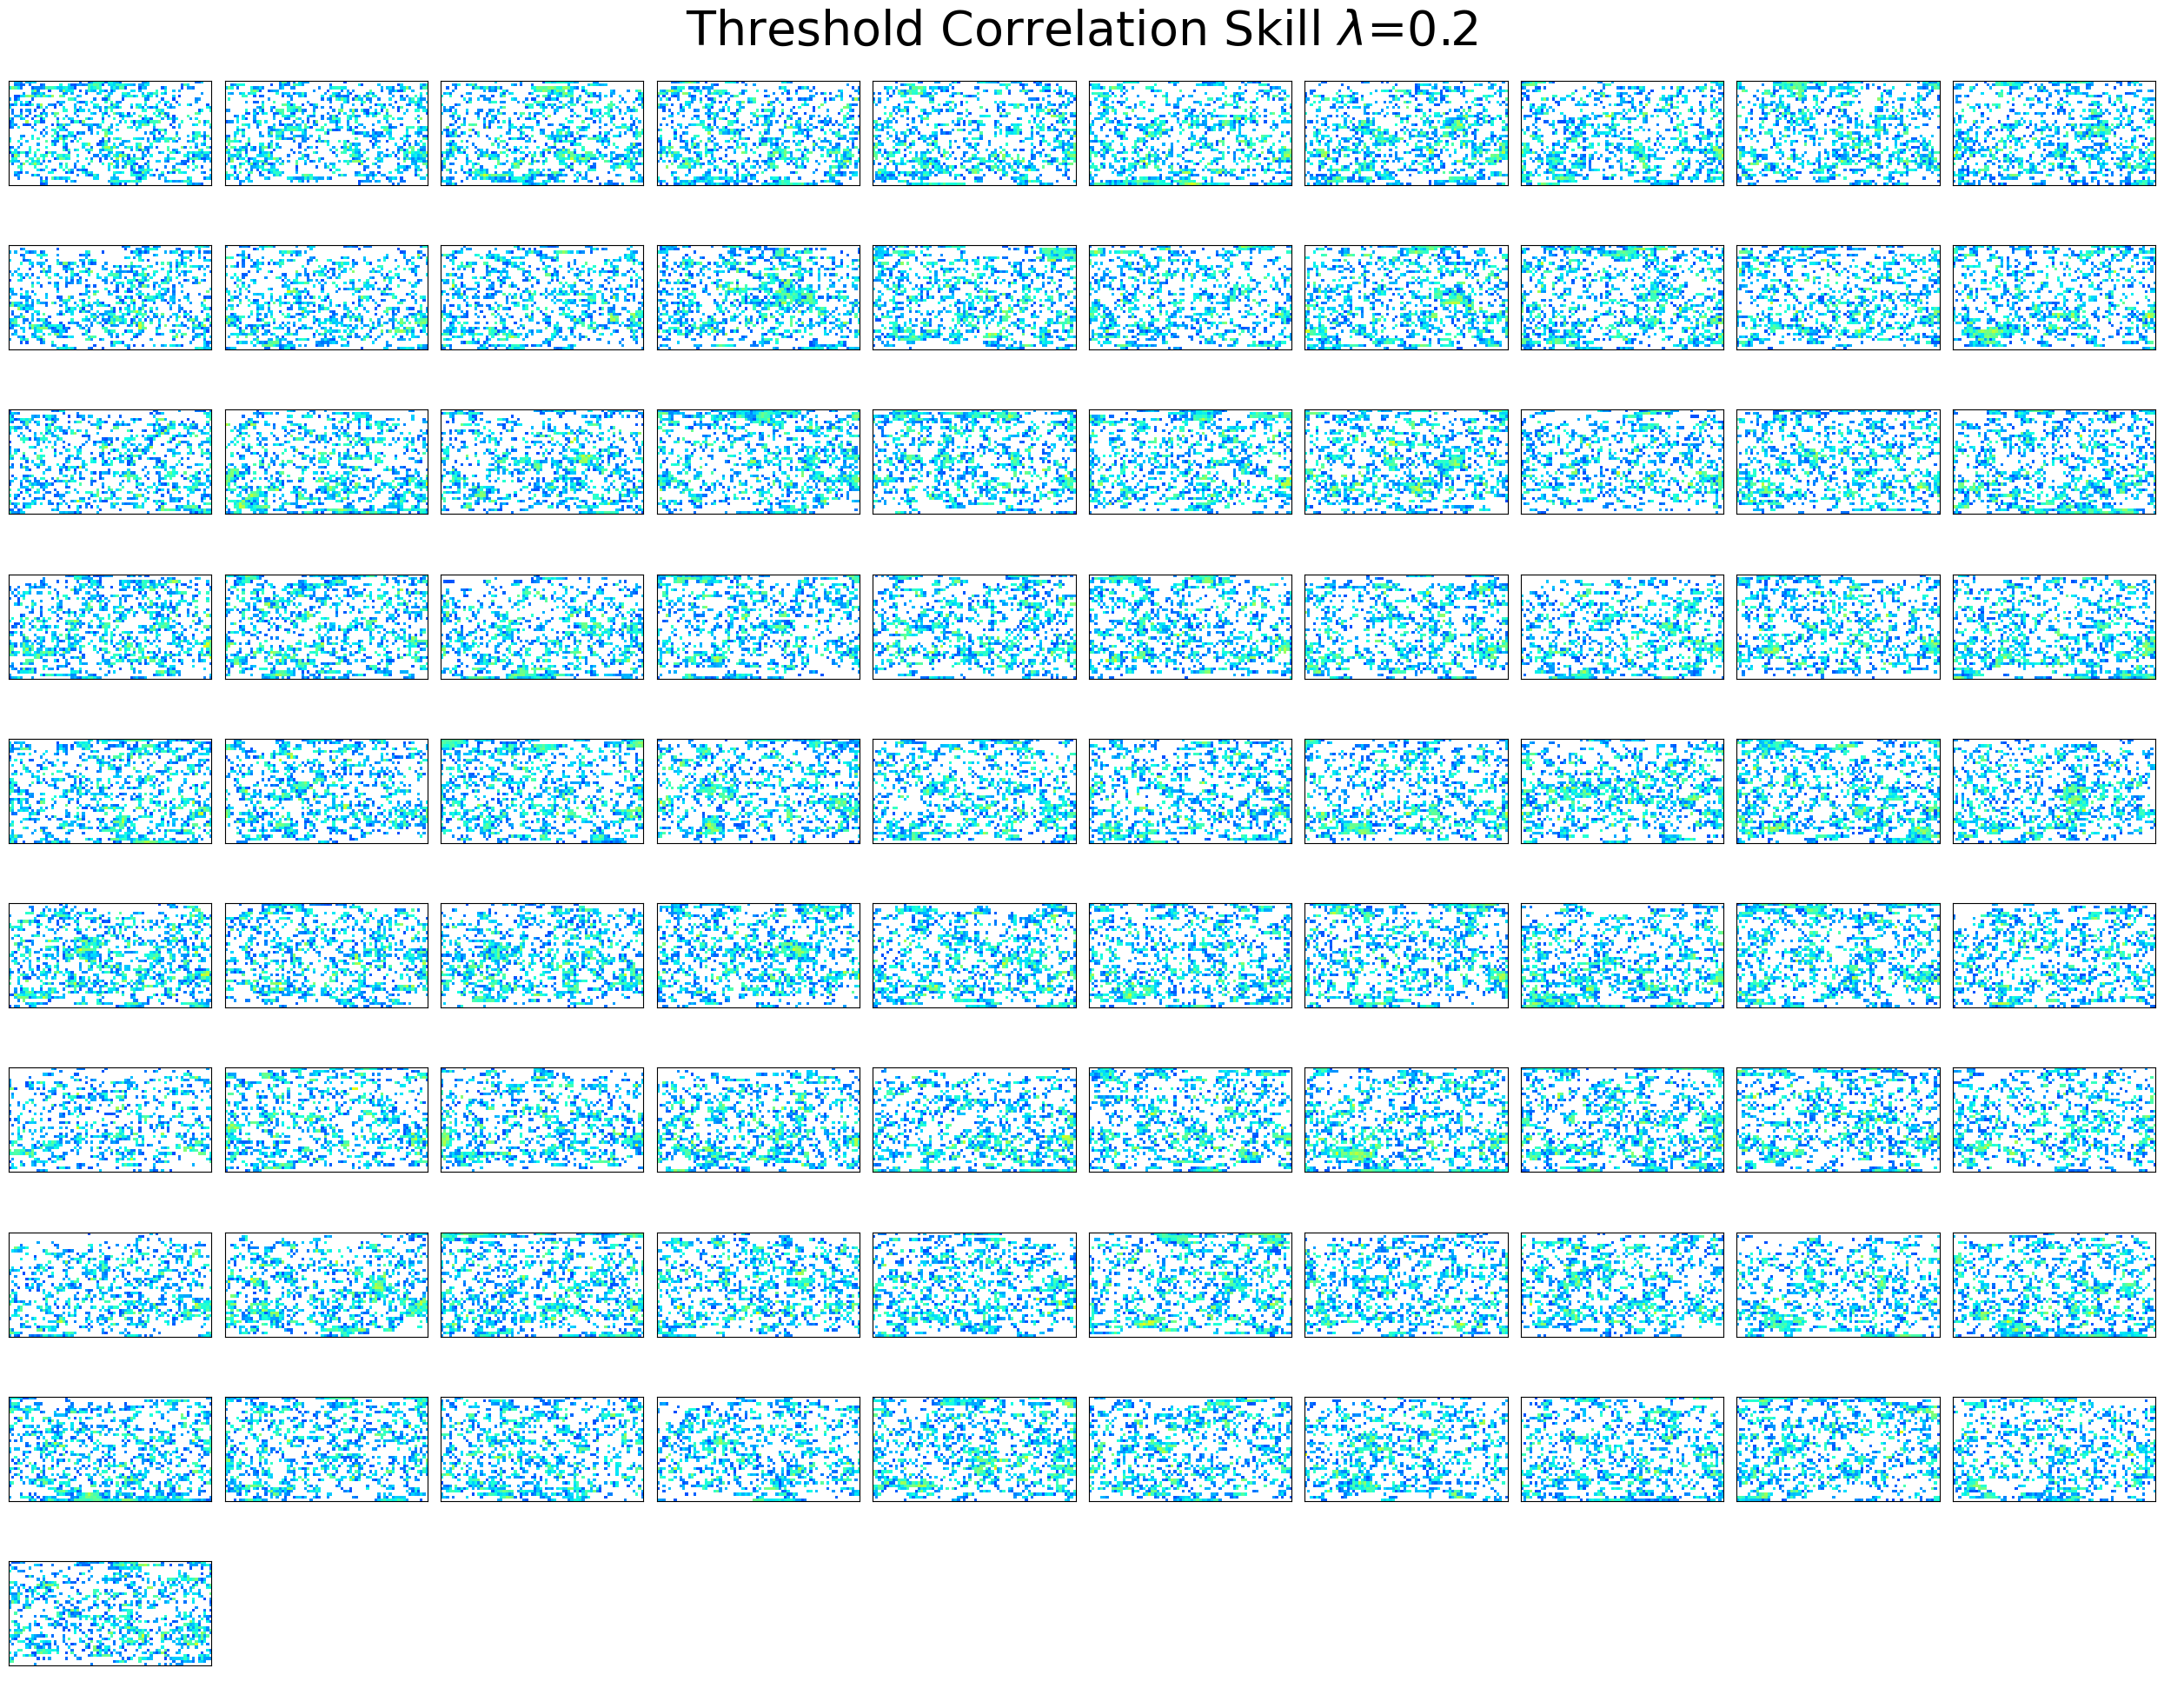

In [214]:
N_SQUARE = 10
CORR_THRESHOLD = 0.2

lam_frac_skill_area = [] 

fig, axs = plt.subplots(N_SQUARE, N_SQUARE, figsize=(25, 20))
axs = axs.flatten()
for i in range(N_SQUARE * N_SQUARE):
    if i<lam_o_pairwise.shape[0]:
        lam_o_tmp = lam_o_pairwise[i, :, :].copy()
        lam_o_tmp[lam_o_tmp<CORR_THRESHOLD] = np.nan
        frac_skill_area.append(np.sum(np.where(np.isnan(lam_o_tmp.flatten()), 0.0, 1.0))/rho_o_tmp.size)
        axs[i].imshow(lam_o_tmp, cmap='jet', vmin=0, vmax=1.0)
        # axs[i].set_title(f'$n={i}$', fontsize=20)
    else:
        for spine in ["top", "bottom", "left", "right"]:
            axs[i].spines[spine].set_visible(False)
        
remove_ticks(axs)
plt.suptitle(f'Threshold Correlation Skill $\\lambda$={CORR_THRESHOLD}', fontsize=40)
plt.tight_layout()

Text(0.5, 0.98, '$\\lambda_j=\\frac{\\text{max}_{n\\neq j}\\,\\hat \\lambda(f_n; o)}{\\text{max}_{n\\neq j}\\,\\hat \\lambda(f_n; f_j)}$')

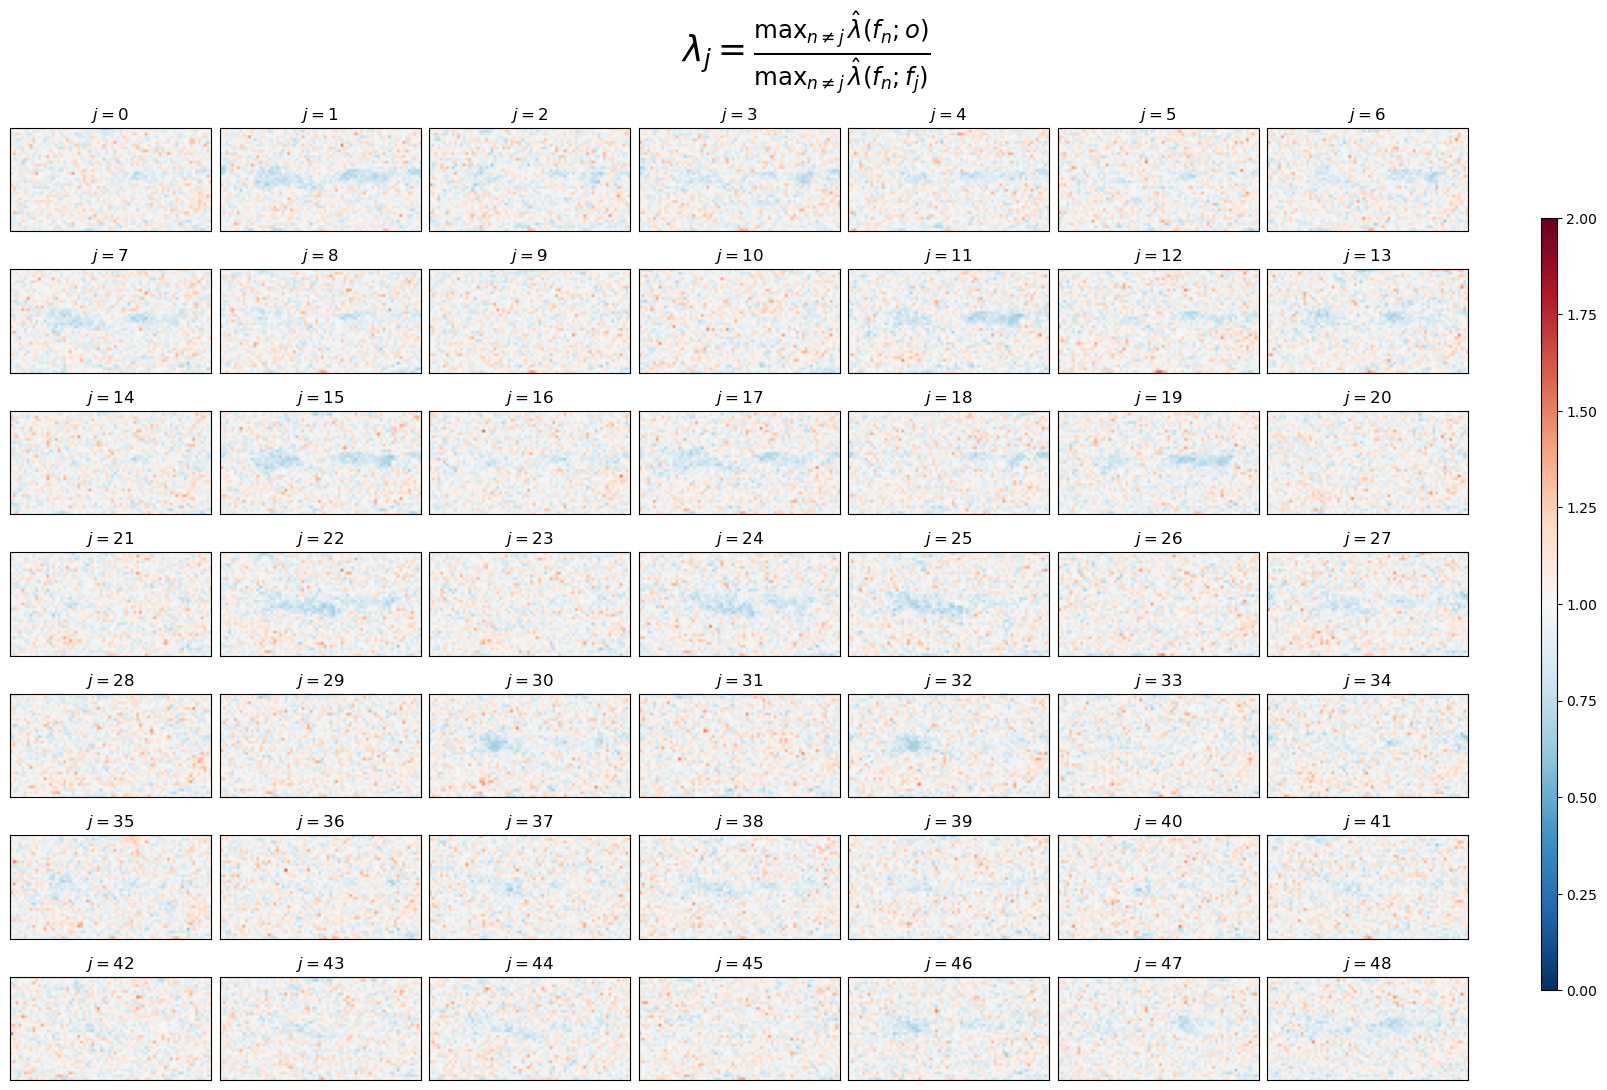

In [309]:
# 1. Add layout="compressed" to your figure initialization
fig, axs = plt.subplots(7, 7, figsize=(16, 12), layout="compressed")
axs = axs.flatten() 

for i in range(len(axs)):
    if i < lam_m_pairwise.shape[0]:
        # compute maximum potential skill of ensemble on obs
        obs_pairwise = lam_o_pairwise.copy() 
        obs_pairwise[i, :, :] = np.nan 
        lam_o_max = np.nanmax(obs_pairwise, axis=0)

        # compute maximum potential skill of ensemble on held-out member
        member_pairwise = lam_m_pairwise[i, :, :, :].copy()
        member_pairwise[i, :, :] = np.nan
        lam_m_max = np.nanmax(member_pairwise, axis=0)

        # show "RPC"
        im = axs[i].imshow(lam_o_max / lam_m_max, vmin=0, vmax=2.0, cmap='RdBu_r')
        axs[i].set_title(f'$j={i}$')
    else:
        for spine in ["top", "bottom", "left", "right"]:
            axs[i].spines[spine].set_visible(False)
            
remove_ticks(axs)

# 2. Add your global colorbar
fig.colorbar(im, ax=axs.ravel(), orientation="vertical", shrink=0.8, aspect=50)   

# 3. Add suptitle (it naturally centers perfectly now)
plt.suptitle('$\\lambda_j=\\frac{\\text{max}_{n\\neq j}\\,\\hat \\lambda(f_n; o)}{\\text{max}_{n\\neq j}\\,\\hat \\lambda(f_n; f_j)}$', fontsize=25)


In [256]:
import numpy as np
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests


def test_RPC(rpc_arr, alpha=0.05, min_members=30):
    """
        Two-sided one-sample t-test of mean RPC against 1. 
        rpc_arr: (N_MEMBER, N_LAT, N_LON)
        
    Returns
        -------
        mean_rpc : ndarray
            Ensemble-mean RPC at each grid cell.
        p_value : ndarray
            Raw two-sided t-test p-value at each grid cell.
        q_value : ndarray
            P-value adjusted for multiple grid-cell tests using FDR.
        significant : ndarray of bool
            True where the FDR-adjusted q-value is below `alpha`.
        n_valid : ndarray
            Number of finite ensemble members available at each grid cell.
    """
    rpc_arr = np.asarray(rpc_arr, dtype=float)
    mean_rpc = np.nanmean(rpc_arr, axis=0)
    n_valid = np.sum(np.isfinite(rpc_arr), axis=0)

    result = ttest_1samp(rpc_arr, popmean=1.0, axis=0, nan_policy="omit", alternative="greater")

    p_value = result.pvalue
    p_value[n_valid < min_members] = np.nan

    # Correct for testing many grid cells.
    q_value = np.full_like(p_value, np.nan)
    significant = np.zeros(p_value.shape, dtype=bool)

    valid = np.isfinite(p_value)
    if np.any(valid):
        reject, corrected_p, _, _ = multipletests(
            p_value[valid],
            alpha=alpha,
            method="fdr_bh",
        )
        q_value[valid] = corrected_p
        significant[valid] = reject

    return mean_rpc, p_value, q_value, significant, n_valid

In [ ]:
# 1. Add layout="compressed" to your figure initialization
fig, axs = plt.subplots(1, 2, figsize=(15, 6), layout="compressed")
axs = axs.flatten() 

N_MEMBER, N_LAT, N_LON = F.shape[0], F.shape[2], F.shape[3]
rho_RPC_arr = np.nan * np.ones((N_MEMBER, N_LAT, N_LON))
lam_RPC_arr = np.nan * np.ones((N_MEMBER, N_LAT, N_LON))

for i in range(N_MEMBER):
    # compute maximum potential skill of ensemble on obs
    lam_obs_pairwise = lam_o_pairwise.copy() 
    rho_obs_pairwise = rho_o_pairwise.copy() 
    lam_obs_pairwise[i, :, :] = np.nan 
    rho_obs_pairwise[i, :, :] = np.nan 
    lam_obs_max = np.nanmax(lam_obs_pairwise, axis=0)
    rho_obs_max = np.nanmax(rho_obs_pairwise, axis=0)

    # compute maximum potential skill of ensemble on held-out member
    lam_member_pairwise = lam_m_pairwise[i, :, :, :].copy()
    rho_member_pairwise = rho_m_pairwise[i, :, :, :].copy()
    lam_member_pairwise[i, :, :] = np.nan
    rho_member_pairwise[i, :, :] = np.nan
    lam_member_max = np.nanmax(lam_member_pairwise, axis=0)
    rho_member_max = np.nanmax(rho_member_pairwise, axis=0)

    rho_RPC_arr[i, :, :] = rho_obs_max / rho_member_max 
    lam_RPC_arr[i, :, :] = lam_obs_max / lam_member_max 

rho_RPC, _, _, significant_rho_RPC_arr, _ = test_RPC(rho_RPC_arr, alpha=0.05)
lam_RPC, _, _, significant_lam_RPC_arr, _ = test_RPC(lam_RPC_arr, alpha=0.05)

# show "RPC"
im0 = axs[0].imshow(rho_RPC, vmin=0, vmax=2.0, cmap='RdBu_r', interpolation='bilinear')
im1 = axs[1].imshow(lam_RPC, vmin=0, vmax=2.0, cmap='RdBu_r', interpolation='bilinear')
ims = [im0, im1]

# for ax, significant in zip(
#     axs,
#     [significant_rho_RPC_arr, significant_lam_RPC_arr],
# ):
#     y, x = np.where(significant)
#     ax.scatter(x, y, s=4, c="black", marker="x", linewidths=0.5)

axs[0].set_title('mean$_j$ $\\rho_j$', fontsize=15)
axs[1].set_title('mean$_j$ $\\lambda_j$', fontsize=15)
            
remove_ticks(axs)
add_colorbars(fig, ims, axs, fraction=0.023, pad=0.03)


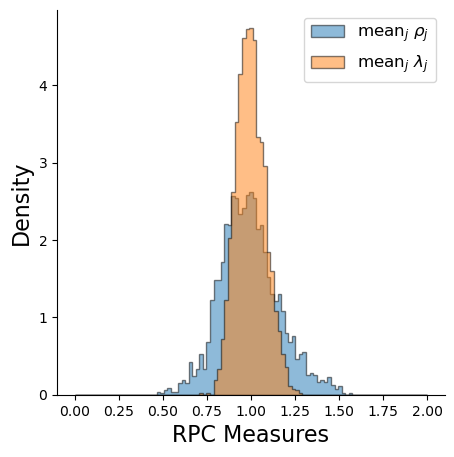

In [287]:
FONT_SIZE = 16

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.hist(rho_RPC.flatten(), bins=np.linspace(0, 2, 100), 
        histtype='stepfilled', ec='k', alpha=0.5, density=True, label='mean$_j$ $\\rho_j$')
ax.hist(lam_RPC.flatten(), bins=np.linspace(0, 2, 100), 
        histtype='stepfilled', ec='k', alpha=0.5, density=True, label='mean$_j$ $\\lambda_j$')
ax.set_xlabel('RPC Measures', fontsize=FONT_SIZE)
ax.set_ylabel('Density', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE-4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)